## Replicating Experiment for A/B Testing 
### Problem Statement: 
**Context**: In Competitive e-commerce market, Minimizing friction during the checkout process is critical for maximizing revenues. 

1. **Situation**: Company is seeing a high drop rate at its payment information step. 
2. **Task**: Improve conversions 
3. **Proposition**: The product team proposed a new checkout flow termed "One-Click Checkout" to streamline the process. 
4. **Expected Insight** : A pilot has been run. We have to check if the new product proposition is actually improving the conversions, or is it just on paper. We need to determine if the variant statistically outperforms the control in terms of overall conversion rate and also understand its impact on different segments (channel,user type).
5. **Why it matter**: It is important, as an improvement and conversions, let it be 1%, It can translate into millions of dollars of revenue. But blindly implementing Can bring an unforeseen negative impact on customer retention or average order value. 

### Objective:
This analysis aims to achieve the following:
1. **Exploratory Goal:** Understand the baseline distributions of cart values, time spent, and conversion rates across different user demographics.
2. **Preprocessing Goal:** Clean and prepare the hypothetical dataset, handling missing values and scaling features appropriately.
3. **Statistical Goal 1:** Conduct a rigorous Frequentist A/B test (Two-Proportion Z-Test) to evaluate the primary conversion metric.
4. **Statistical Goal 2:** Apply a Logistic Regression model to control for confounding variables and estimate the causal impact of the new checkout flow.
5. **Business Goal:** Provide actionable recommendations based on the statistical findings, including segment-specific strategies.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, ttest_ind, probplot
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Set aesthetic style for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

## Dataset and Overview: 
Generating robust hypothetical dataset representing A/B test for 2 weeks 

* **`User_ID`**: 5 digit unique ID for user
* **`Order_ID`**: 7 Digit order ID 
* **`Cart_Value`**: Total value of the items in cart before checking out
* **`time_spent_min`**: Total time spent (minutes) in the session before checking out.
* **`device_type`**: Laptop / Tablet / Mobile
* **`User_type`**: New / Returning
* **`group`** : Control (Original) / Variant (One-Click Checkout)
* **`Converted`** :  Yes (1) / No (0)


**Assumptions & Potential Issues:**
* The assignment to Control/Variant is completely randomized (i.e., no assignment bias).
* The events are independent and identically distributed (i.i.d).
* We will intentionally introduce some missing data in `time_spent_mins` to demonstrate robust preprocessing techniques.

**Realistic Scenarios**
* Bias is possible to be present within segmentation. will be taken care by logistic regression while presenting evidence within user segmentation. 


In [3]:
# Set random seed for reproducibility
np.random.seed(200)

# Dataset generation
n_sample = 10000
user_ids = [f"{i:05d}" for i in range(1, n_sample + 1)]
order_id = [f"{i:07d}" for i in range(1, n_sample + 1)]
groups = np.random.choice(['control', 'treatment'], size=n_sample, p=[0.5, 0.5])
device_type = np.random.choice(['mobile', 'desktop', 'tablet'], size=n_sample, p=[0.6, 0.10, 0.30])
user_type = np.random.choice(['new', 'returning'], size=n_sample, p=[0.4, 0.6])

# Log-normal distribution to mimic real quick commerce data: Cart Value and time spent
# Simulating cart values: 
cart_value = np.random.lognormal(mean=6.2, sigma=0.5, size=n_sample)  # assuming median around 500, most lie between (300 and 800)
cart_value = np.round(np.clip(cart_value, 5, 5000), 2) # bounding between 5 - 5000 to avoid extreme outliers

# Simulating time spent on site (in minutes)
time_spent_min = np.random.lognormal(mean=1.6, sigma=0.9, size=n_sample)  # median around 5 minutes, most between 2 and 12 minutes
time_spent_min = np.round(np.clip(time_spent_min, 0.5, 45), 2) # decision, selection, checkout

# Introducing complexities:
# introducing missing values randomly in time_spent_min (assuming 5% missing)
missing_idx = np.random.choice(n_sample, size=int(0.05 * n_sample), replace=False)
time_spent_min[missing_idx] = np.nan

# Instead of dritectly generating conversion, we will create a probability of conversion logits
# Baseline conversion log-odds
logits = -1.5 
# Effect of Variant
logits += np.where(groups == 'Variant', 0.25, 0)
# Effect of Device (Mobile is easier to convert)
logits += np.where(device_type == 'Desktop', 0.3, 0)
# Effect of Customer Type (Returning convert more)
logits += np.where(user_type == 'Returning', 0.5, 0)
# Effect of Cart Value (Higher carts slightly less likely to convert directly)
logits -= cart_value * 0.001

# calculating probabilities for sigmoid function
probs = 1 / (1 + np.exp(-logits))
conversion = np.random.binomial(1, probs) # either n,success prob, sample size / n trails, array of probability

# Dataframe creation:
data = pd.DataFrame({
    'user_id': user_ids,
    'order_id': order_id,
    'group': groups,
    'device_type': device_type,
    'user_type': user_type,
    'cart_value': cart_value,
    'time_spent_min': time_spent_min,
    'conversion': conversion
})

In [6]:
# conversion check
np.sum(data['conversion'])*100/10000
data.groupby('group')['conversion'].mean()
 

group
control      0.105439
treatment    0.125254
Name: conversion, dtype: float64

In [7]:
display(data.head())
print(data.shape)
data.info()


,user_id,order_id,group,device_type,user_type,cart_value,time_spent_min,conversion
0,00001,0000001,treatment,mobile,returning,280.74,5.38,0
1,00002,0000002,control,mobile,returning,207.18,2.95,1
2,00003,0000003,treatment,mobile,returning,455.63,1.99,0
3,00004,0000004,control,mobile,returning,355.30,8.62,0
4,00005,0000005,treatment,desktop,new,584.44,1.25,0


(10000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         10000 non-null  str    
 1   order_id        10000 non-null  str    
 2   group           10000 non-null  str    
 3   device_type     10000 non-null  str    
 4   user_type       10000 non-null  str    
 5   cart_value      10000 non-null  float64
 6   time_spent_min  9500 non-null   float64
 7   conversion      10000 non-null  int32  
dtypes: float64(2), int32(1), str(5)
memory usage: 586.1 KB


### Interpretation:
We have successfully creation a synthetic data which would mimic the quick commerce dataset of 10K unique users. The distributions and relationships built into the logits (e.g., returning users converting at higher rates, mobile devices showing lower conversion) will allow us to demonstrate both confounding and segment analysis later. Info() command showcases the missing value present in the dataset.

--- 

## Data Preprocessing:
**Target:** cleaning the dataset and making it ready for modeling / analysis.

### Handling Missing Values:
`time_spent_min` is dependent on the `device_type` (mobile / tab / Laptop) and `user_type` (new/repeat). Need to input average values present for these subgroups for filling up null value in order to preserve the underlying distribution without getting skewed by extreme outliers.
It is important to check how the focus feature does interact with other features which deciding the values.

In [8]:
# Analyzing missing values, initially, checking the percentage makes more sense to understand the scale of the issue
missing_pc = data.isnull().mean() * 100
print("Missing Values Percentage columns:\n", missing_pc[missing_pc > 0])

# Handling missing values in time_spent_min by imputation (using median)
data['time_spent_min'] = data.groupby(['device_type','user_type'])['time_spent_min'].transform(lambda x: x.fillna(x.median()))

print(f"Remaining missing values: {data.isnull().sum().sum()}")

Missing Values Percentage columns:
 time_spent_min    5.0
dtype: float64
Remaining missing values: 0


### Outlier Detection:
Visually inspecting the cart values and time_spent_min for extreme outiers that might skew the revenue based metrics

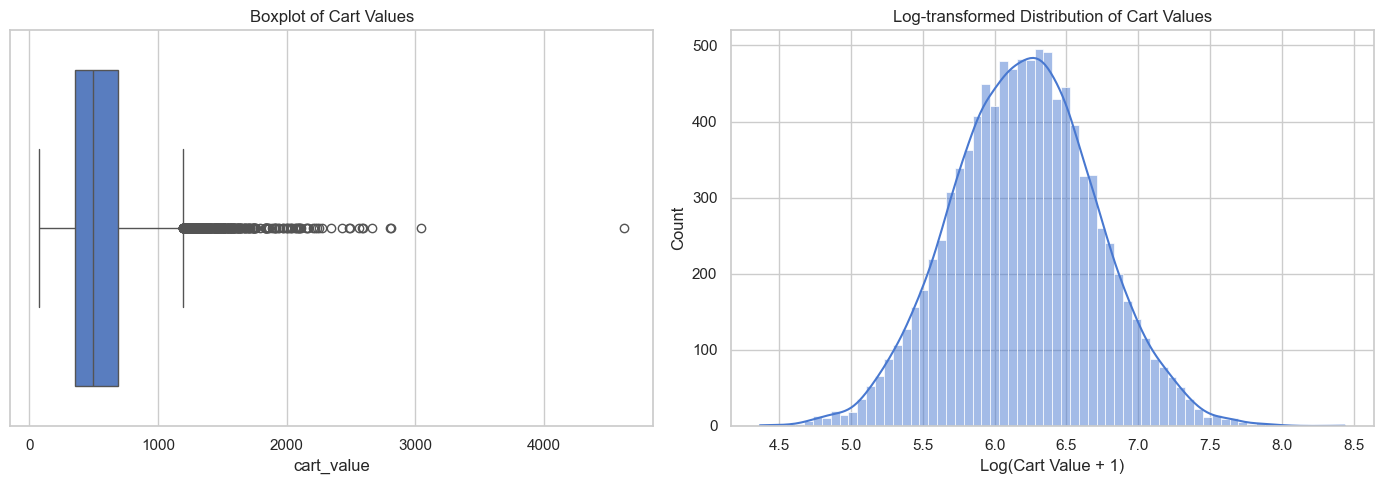

In [9]:
# Outlier detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=data, x='cart_value', ax=axes[0])
axes[0].set_title('Boxplot of Cart Values')

# Log-transformed visualization
sns.histplot(np.log1p(data['cart_value']), kde=True, ax=axes[1])
axes[1].set_title('Log-transformed Distribution of Cart Values')
axes[1].set_xlabel('Log(Cart Value + 1)')

plt.tight_layout()
plt.show()

In [10]:
# percentage of datapoints outside whisker
Q1 = data['cart_value'].quantile(0.25)
Q3 = data['cart_value'].quantile(0.75)

IQR = Q3 - Q1

lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

outliers = data[
    (data['cart_value'] < lower_whisker) |
    (data['cart_value'] > upper_whisker)
]

print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {100*len(outliers)/len(data):.2f}%")

Number of outliers: 395
Percentage of outliers: 3.95%


**Outlier Strategy:**
Our `cart_value` was generated with an upper clip of Rs 5000, simulating a natural cap or a pre-filtering step often done in e-commerce to separate wholesale / kirana stores from retail (Individuals). The log-transformation shows a beautiful normal-like distribution, confirming that our values are highly right-skewed but manageable. 
We will not drop outliers as they represent valid (and highly valuable) purchases (only ~4% of the data points are outside whiskers: 5-15% is common for log-normal data), but we will apply standard scaling to numerical features before running the logistic regression later to ensure convergence.

---
### 5. Exploratory Data Analysis
#### 5.1 Overall Conversion & Group Balance - Univariate Analysis

`Confirming if the A/B test groups are balanced and look at conversion rates`
Using EDA, I am trying to figure out if there is anything about the data I should know which can either make my results inconclusive / give me addition insight about the business recommendations I can make using the data of A/B testing  

**For actual success of test**
1. Signal > Noise : Signal / Noise = significance 
2. No Skewness due to some imbalance in distribution b/w control and treatment (ex: % of mobile channels)
3. Enough data to actually understand it generated results (2 weeks vs 2 months) 
4. High number of outliers - high variance - wider confidence interval - kills significance : a problem

**Basic checks in data for test validity**
1. Did the randomization of data worked properly (possibility of SRM - sample ratio mismatch) 



In [197]:
# contribution of groups in value counts
data['group'].value_counts(normalize=True)

group
control      0.5074
treatment    0.4926
Name: proportion, dtype: float64

In [200]:
 data.groupby('group')['conversion'].mean().iloc[1]- data.groupby('group')['conversion'].mean().iloc[0]

np.float64(0.019814260115535692)

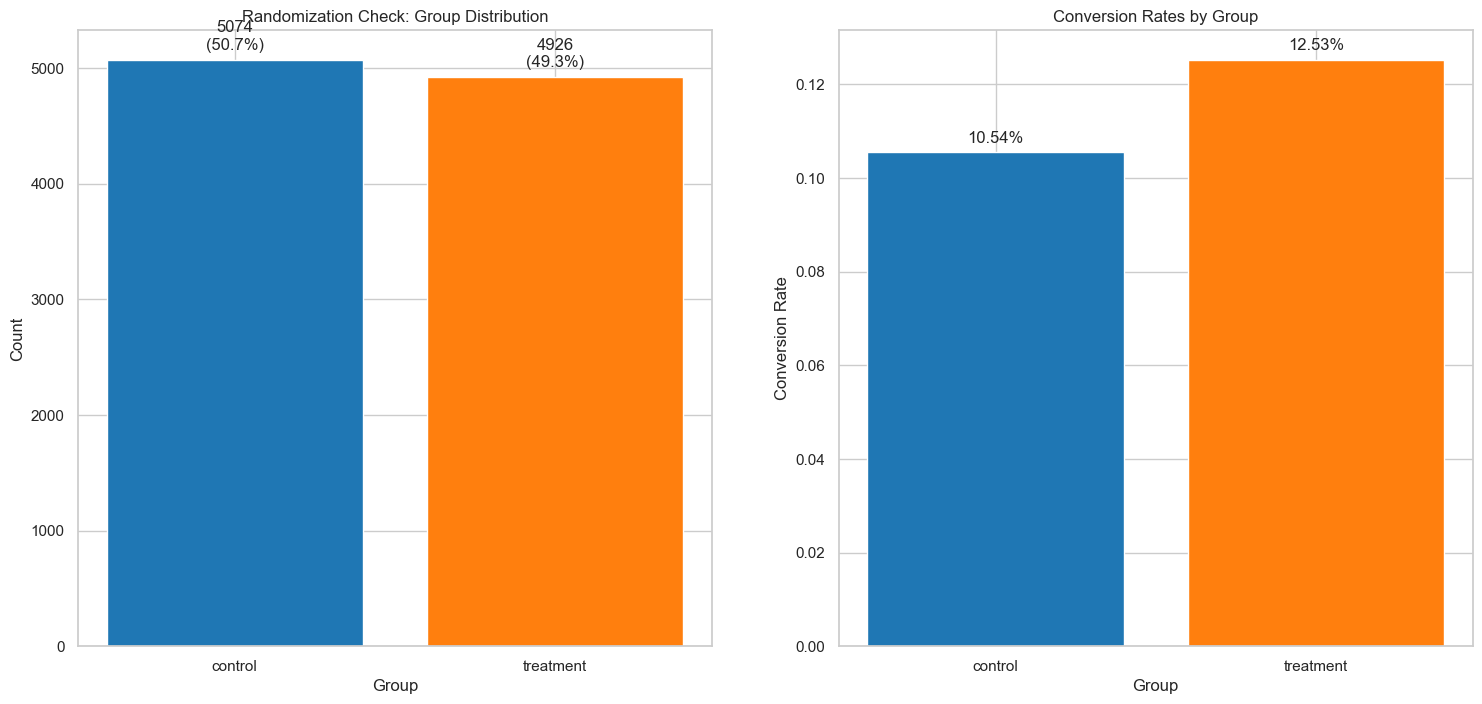

In [11]:
# Randomization check:
fig,axes = plt.subplots(1, 2, figsize=(18, 8))

# using the 1st subplot for bar plot
axes[0].bar(data['group'].value_counts().index, data['group'].value_counts().values, color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Randomization Check: Group Distribution')    
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Count')


# labeling and additing % of each group
total = len(data)
for p in axes[0].patches:
    height = p.get_height()
    percentage = f'{height}\n({height/total*100:.1f}%)'
    axes[0].annotate(percentage, (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

# 2nd subplot for conversion rates by group
conversion_rates = data.groupby('group')['conversion'].mean()
axes[1].bar(conversion_rates.index, conversion_rates.values, color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Conversion Rates by Group')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Conversion Rate')

# labeling and additing % of conversion rates
for p in axes[1].patches:
    height = p.get_height()
    percentage = f'{height*100:.2f}%'
    axes[1].annotate(percentage, (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

**Interpretation** 
* **Sample size check:** The trafic split is practically 50/50, proves that our randomization worked and there is no sample ratio mismatch (SRM)
* **Conversion Lift:** The conversion rate of the control is 10.54% and the treatment is 12.53%, the absolute lift being 2.5%. Visually, it looks promising, but we need statistically test the significance of the result, whether this lift is actually good or is it just some random noise.

--- 

####  5.2 Segment Analysis (Device Type & User Type) :  Bivariate Analysis  
Lets see how conversion behaviour (Target variable) is across segments

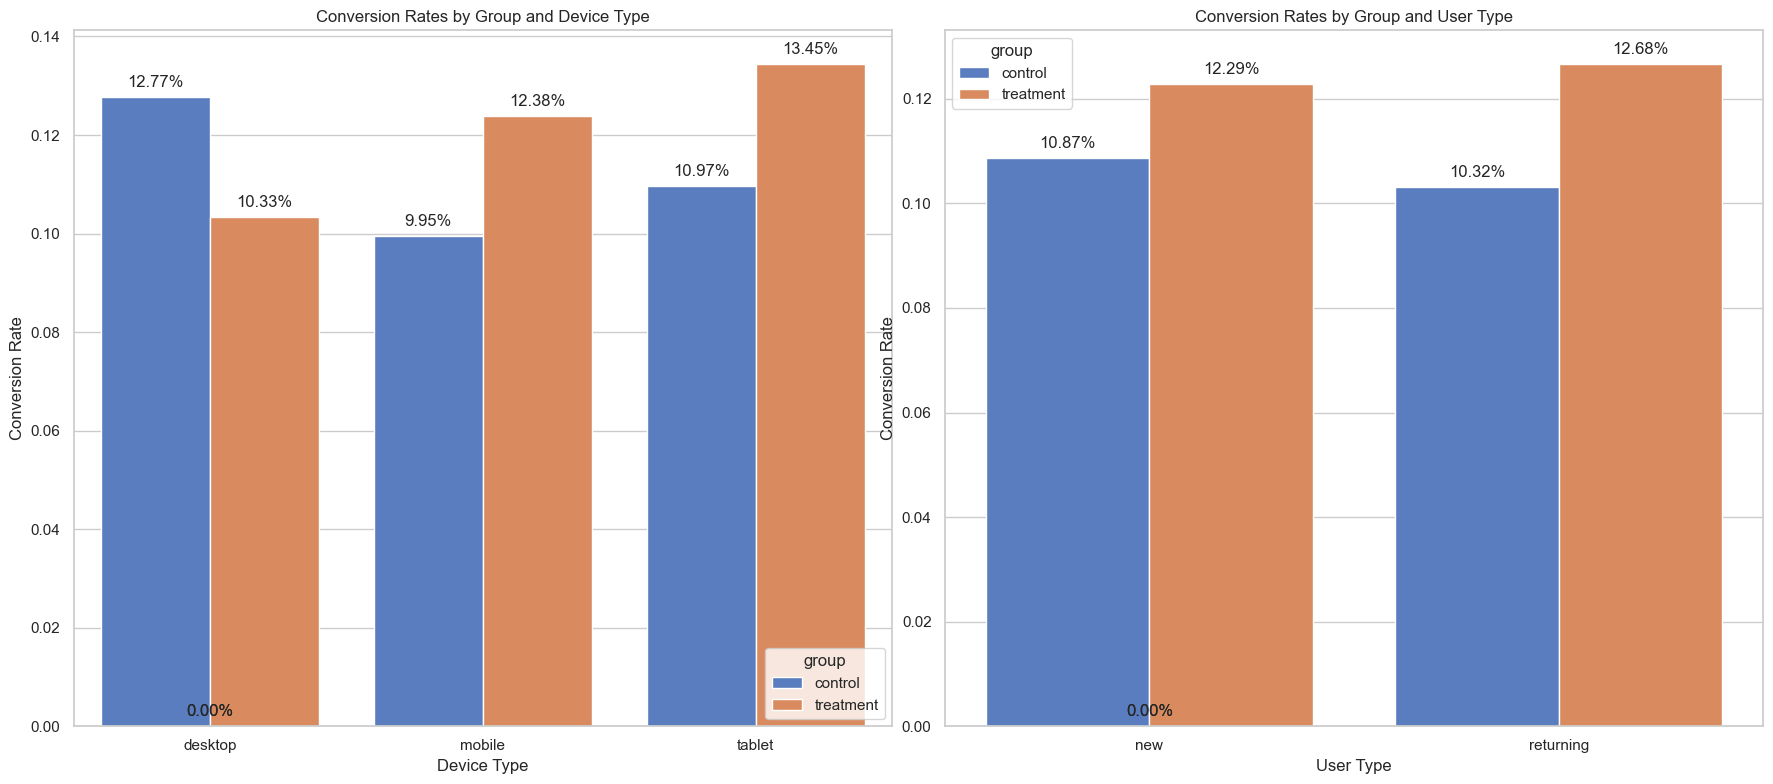

In [208]:
fig,axes = plt.subplots(1, 2, figsize=(18, 8))

df = data.groupby(['group', 'device_type'])['conversion'].mean().reset_index()
sns.barplot(data=df, x='device_type', y='conversion', hue='group', ax=axes[0])
axes[0].set_title('Conversion Rates by Group and Device Type')
axes[0].set_xlabel('Device Type')
axes[0].set_ylabel('Conversion Rate')

plt.tight_layout()

# labeling and additing % of conversion rates
for p in axes[0].patches:
    height = p.get_height()
    percentage = f'{height*100:.2f}%'
    axes[0].annotate(percentage, (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
    
df = data.groupby(['group', 'user_type'])['conversion'].mean().reset_index()
sns.barplot(data=df, x='user_type', y='conversion', hue='group', ax=axes[1])
axes[1].set_title('Conversion Rates by Group and User Type')
axes[1].set_xlabel('User Type')
axes[1].set_ylabel('Conversion Rate')

# labeling and additing % of conversion rates
for p in axes[1].patches:    
    height = p.get_height()
    percentage = f'{height*100:.2f}%'
    axes[1].annotate(percentage, (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

In [ ]:
# checking if there is increment in high value customers across device types
def high_value(x):
    IQR = x.describe()['75%'] - x.describe()['25%']
    upper_whisker = x.describe()['75%'] + 1.5*IQR
    lower_whisker = x.describe()['25%'] - 1.5*IQR
    outliers = x[
    (x > upper_whisker)
    ]

    return outliers.count() 

data[(data['conversion']==1)].groupby(['group', 'device_type'])['cart_value'].agg(high_value).reset_index()

,group,device_type,cart_value
0,control,desktop,4
1,control,mobile,8
2,control,tablet,7
3,treatment,desktop,1
4,treatment,mobile,8
5,treatment,tablet,12


In [57]:
print('average time spent by converted users')
display(data[(data['conversion']==1)].groupby(['group', 'device_type'])['time_spent_min'].mean().reset_index())

print('average time spent by non converted users')
data[(data['conversion']==0)].groupby(['group', 'device_type'])['time_spent_min'].mean().reset_index()

average time spent by converted users


,group,device_type,time_spent_min
0,control,desktop,6.633538
1,control,mobile,6.506033
2,control,tablet,7.722765
3,treatment,desktop,6.213404
4,treatment,mobile,7.625868
5,treatment,tablet,7.764010


average time spent by non converted users


,group,device_type,time_spent_min
0,control,desktop,7.513018
1,control,mobile,7.291929
2,control,tablet,7.094532
3,treatment,desktop,7.340637
4,treatment,mobile,7.532526
5,treatment,tablet,7.093101


**Interpretation**
1. **Device Type:** Conversion rate of desktop decreased (about 10% of population) while of the mobile and table increased which constitutes of 90% population. 
2. **User Type:** Conversion improved for both new and returning users where higher conversion is being observed for returning user, which indicates a positive sign for business showcasing improvement in loyal customer base. Variant appears to benefit both segments positively
3. **High value customers:**  High value customers conversion doubled for tablet and decreased significantly for desktop where as for mobile it stayed the same.  

---

### 5.3 Corellation Analysis: : Bivariate Analysis 


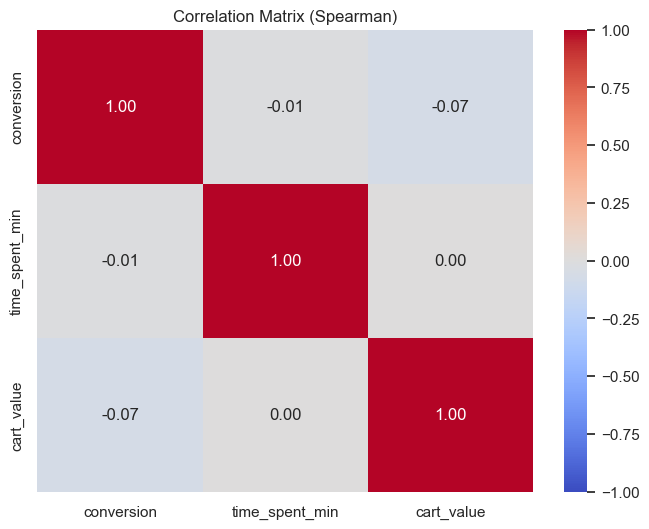

In [209]:
corr_df = data[['conversion','time_spent_min','cart_value']]
corr_matrix = corr_df.corr(method='spearman')  # Spearman for non-linear/binary robust stats

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix (Spearman)')
plt.show()

**Interpretation**
1. A weak negative correlation (< 0.1) b/w of conversion and cart_value. Larger cart value might require a deliberate focus, thus converting less frequently in a session
2. The correlations are generally weak, which emphasis the need for multivariate causal analysis rather than relying on simple linear bivariate relationships

---

## 6. Statistical Hypothesis Testing

### 6.1. Two-Proportion Z-Test (Frequentist Approach)
We want to test if the observed effect (Variant > Control) is statistically significant.

**Hypotheses:**
* **$H_0$ (Null):** $P_{variant} - P_{control} \le 0$ (The new checkout does not increase conversion).
* **$H_1$ (Alternative):** $P_{variant} - P_{control} > 0$ (The new checkout increases conversion).
* **Alpha ($\alpha$):** $0.05$

In [12]:
data['conversion'].mean()
display(data[data['group'] == 'control']['conversion'].mean())
display(data[data['group'] == 'treatment']['conversion'].mean())


np.float64(0.10543949546708711)

np.float64(0.1252537555826228)

In [26]:
# conversion probability (or conversion rate) of control and variant
control_p = data[data['group'] == 'control']['conversion'].mean()
variant_p = data[data['group'] == 'treatment']['conversion'].mean()

# assuming the null hypothesis stands, we can calculate the pooled probability as the overall conversion rate across both groups
pooled_p = data['conversion'].mean()

# standard error: possible noise
se = np.sqrt(pooled_p * (1 - pooled_p) * (1/data[data['group'] == 'control'].shape[0] + 1/data[data['group'] == 'treatment'].shape[0]))

# checking lift against the noise
z = (variant_p - control_p) / se

p_value = 2 * (1 - norm.cdf(abs(z)))  # two-tailed test


print(f"Control Conversion: {control_p:.4f}")
print(f"Variant Conversion: {variant_p:.4f}")
print(f"Absolute Uplift:    {(variant_p - control_p):.4f}")
print(f"Relative Uplift:    {((variant_p - control_p) / control_p):.4f}")
print("-" * 30)
print(f"Z-Statistic:        {z:.4f}")
print(f"P-Value:            {p_value:.4e}")

if p_value < 0.05:
    print("\nConclusion: Reject the Null Hypothesis. The uplift is statistically significant.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis. The uplift is not statistically significant.")



Control Conversion: 0.1054
Variant Conversion: 0.1253
Absolute Uplift:    0.0198
Relative Uplift:    0.1879
------------------------------
Z-Statistic:        3.1028
P-Value:            1.9171e-03

Conclusion: Reject the Null Hypothesis. The uplift is statistically significant.


**Interpretation:**
1. Results are statistically significant and sitting well below alpha (0.05)
2. An absolute lift of 1.98% leading to relative uplift 18.8% in conversion. 
3. For Quick Commerce, average conversion rate is between 3 - 8 %, an increase in absolute 2 % is grandly welcomed by business. 

**Business Implication:** we can confidently deploy the "One-Click Checkout" as the result is highly statistically significant.

---

## 7. Causal Inference via Logistic Regression

Significance shows that lift was real and not a random noise. 
While the Z-Test tells us if the effect is significant, it doesn't account for complex confounding relationships (e.g., what if the Variant by chance got slightly more "Returning" customers, who convert easier?). 

To isolate the **Average Treatment Effect (ATE)** of the new checkout flow while controlling for covariates, we will fit a Logistic Regression model.

### 7.1. Feature Engineering and Scaling

In [13]:
df_copy = data.copy()

df_copy['is_variant'] = (df_copy['group']=='treatment').astype(int)

Features = ['device_type','user_type','cart_value','time_spent_min']

df_copy = pd.get_dummies(df_copy, columns = ['device_type','user_type'], drop_first=True)

# converting into log scale for using standard scaler, as both cart value and time spent are right skewed
# log transformation can help in normalizing the distribution and reducing the impact of outliers, making the data more suitable for modeling.
df_copy['cart_value'] = np.log1p(df_copy['cart_value'])
df_copy['time_spent_min'] = np.log1p(df_copy['time_spent_min'])

scaler = StandardScaler()
df_copy[['cart_value','time_spent_min']] = scaler.fit_transform(df_copy[['cart_value','time_spent_min']])

features_scaled = ['is_variant','cart_value','time_spent_min'
                   ,'device_type_mobile','device_type_tablet','user_type_returning']

# Add constant for intercept for regression model for not assuming the regression line passes through the origin
x = sm.add_constant(df_copy[features_scaled].astype(float)) 
y = df_copy['conversion']

# using logit function from statsmodels to perform logistic regression
# statsmodel speciallizes in statistical summary and inference, while sklearn is more focused on prediction and machine learning pipelines.
# Statsmodels provides detailed statistical output, including p-values, confidence intervals, and model diagnostics, which are essential for understanding the significance of predictors in a regression model. On the other hand, sklearn's logistic regression is optimized for predictive performance and may not provide as comprehensive statistical insights.

model = sm.Logit(y, x)
result = model.fit(disp=False)
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:             conversion   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9993
Method:                           MLE   Df Model:                            6
Date:                Fri, 05 Jun 2026   Pseudo R-squ.:                0.008619
Time:                        19:11:08   Log-Likelihood:                -3541.7
converged:                       True   LL-Null:                       -3572.5
Covariance Type:            nonrobust   LLR p-value:                 2.147e-11
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -2.1415      0.113    -18.983      0.000      -2.363      -1.920
is_variant              0.1930      0.063      3.065      0.002       0.070       0.316
cart_value      

### 7.2 Extracting the Treatment Effect

Converting log-odds coefficients into easy interpretable odds ratios

,Odds Ratio,CI Lower,CI Upper,P-Value
is_variant,1.212904,1.072070,1.372240,2.176346e-03
cart_value,0.802470,0.754255,0.853768,3.387816e-12
time_spent_min,0.971098,0.912799,1.033120,3.531706e-01
device_type_mobile,0.957568,0.773400,1.185592,6.907415e-01
device_type_tablet,1.056268,0.843214,1.323155,6.338811e-01
user_type_returning,0.988927,0.872099,1.121406,8.621881e-01


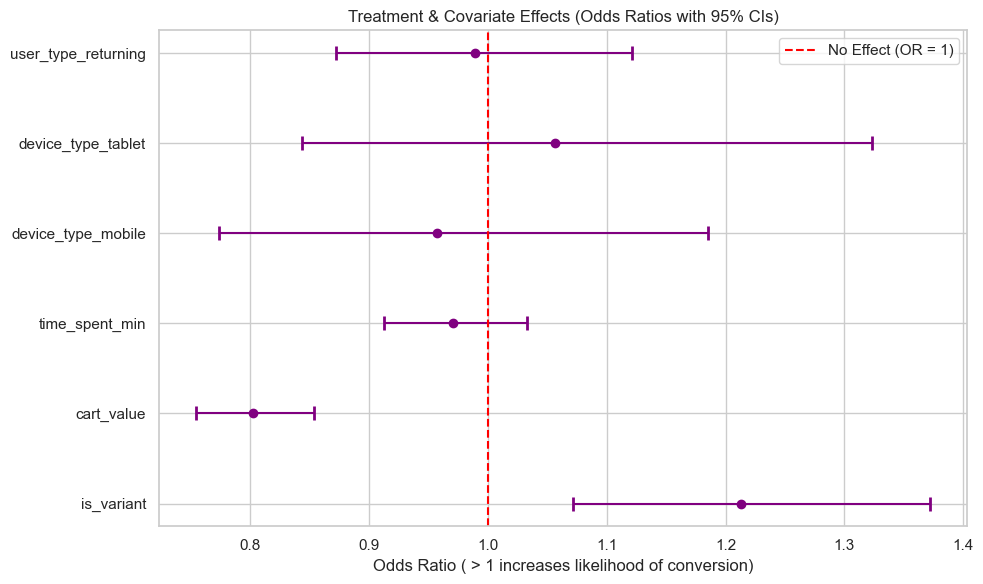

In [14]:
odds_ratios = pd.DataFrame({
    'Odds Ratio': np.exp(result.params),
    'CI Lower': np.exp(result.conf_int()[0]),
    'CI Upper': np.exp(result.conf_int()[1]),
    'P-Value': result.pvalues
})

# Filter out the constant for plotting
odds_ratios = odds_ratios.drop('const')
display(odds_ratios)


plt.figure(figsize=(10, 6))
plt.errorbar(x=odds_ratios['Odds Ratio'], y=odds_ratios.index, 
             xerr=[odds_ratios['Odds Ratio'] - odds_ratios['CI Lower'], 
                   odds_ratios['CI Upper'] - odds_ratios['Odds Ratio']], 
             fmt='o', color='purple', capsize=5, capthick=2)

plt.axvline(x=1, color='red', linestyle='--', label='No Effect (OR = 1)')
plt.title('Treatment & Covariate Effects (Odds Ratios with 95% CIs)')
plt.xlabel('Odds Ratio ( > 1 increases likelihood of conversion)')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:**
1. `is_variant` **Treatment Effect** the odds ratio is ~1.21, this means keeping all the other variables constant, consumers in the treatment group are 21% more likely to convert than customer in control group. p value < 0.5 - ensures statistical significance. No problem or effect of any confounding variable
2. `Cart_value`, this being significant  (p value < 0.05), the odds ratio in ~0.80, which means higher cart value is attracting a lower conversion, indicating some friction for High value cust as also observed in EDA.
3. Other features are not significant and might need larger data for identifying significance.

**Why this matters over the Z-test:** This proves that the 1.98% absolute lift observed initially wasn't a fluke caused by a skewed randomization of returning vs new users. The treatment effect exists strongly even when we control for the environment.

**diving deeper to understand if the user type is really not effecting**

In [21]:
display(data.groupby(['group','user_type'])['conversion'].mean())
# conversions are quite close for new and returning users and the lift in the treatment group is more and positive than in control group
display(data.groupby(['group','user_type'])['conversion'].count())  

group      user_type
control    new          0.108727
           returning    0.103209
treatment  new          0.122934
           returning    0.126756
Name: conversion, dtype: float64

group      user_type
control    new          2051
           returning    3023
treatment  new          1936
           returning    2990
Name: conversion, dtype: int64

In [23]:
# creating a new feature that captures the interaction between being in the treatment group and being a returning user, which can help us understand if the effect of the treatment is different for returning users compared to new users.
df_copy['is_variant_return'] = df_copy['is_variant'] * df_copy['user_type_returning']
# df_copy['is_control_return'] = (df_copy['is_variant'] == 0) * df_copy['user_type_returning']

new_features_scaled = ['is_variant','cart_value','time_spent_min'
                   ,'device_type_mobile','device_type_tablet','user_type_returning','is_variant_return']

x_new = sm.add_constant(df_copy[new_features_scaled].astype(float))
model_new = sm.Logit(y, x_new)
result_new = model_new.fit(disp=False)
print(result_new.summary())


                           Logit Regression Results                           
Dep. Variable:             conversion   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9992
Method:                           MLE   Df Model:                            7
Date:                Fri, 05 Jun 2026   Pseudo R-squ.:                0.008685
Time:                        19:36:02   Log-Likelihood:                -3541.5
converged:                       True   LL-Null:                       -3572.5
Covariance Type:            nonrobust   LLR p-value:                 5.857e-11
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -2.1138      0.119    -17.694      0.000      -2.348      -1.880
is_variant              0.1400      0.099      1.408      0.159      -0.055       0.335
cart_value      

**Interpretation:**
1. There is no stonger evidence that variant is for a particular user type

--- 
### Financial Implication:

To turn odds ratios and statistical significance into business language, Let's simulate an annual revenue impact it will generate if we roll this to 100% of the traffic. 

* **Assumptions:** 
    * 2.4L visitors per month ( 28.8L / year) (performed a guesstimate)
    150cr -> 45cr (30% urban) -> 31cr (70% digital savvy) ->  3.1cr (200/2000 cities blinkit servicable) -> 12L (40% middle class) -> 8L (2/3 interest in online buying) -> 2.4L (30% market share)
    * Average Order Value (AOV) = 500 (derived from our cart median).

In [30]:
Annual_visitor = 2880000
aov = data['cart_value'].median()

control_conversion = Annual_visitor * control_p * aov
treatment_conversion = Annual_visitor * variant_p * aov
incremental_revenue =  treatment_conversion - control_conversion
inc_pct = round(incremental_revenue * 100 / control_conversion,2)

print(f"Estimated AOV: ${aov:.2f}")
print(f"Projected Annual Revenue (Control Flow): Rs{control_conversion:,.2f}")
print(f"Projected Annual Revenue (Variant Flow): Rs{treatment_conversion:,.2f}")
print(f"\nProjected Incremental Revenue: Rs{incremental_revenue:,.2f} ({inc_pct}%) per year")


Estimated AOV: $494.78
Projected Annual Revenue (Control Flow): Rs150,249,256.60
Projected Annual Revenue (Variant Flow): Rs178,484,196.83

Projected Incremental Revenue: Rs28,234,940.23 (18.79%) per year


## CONCLUSION AND RECOMMENDATIONS:

1. **Clear winner**: Variant to be implemented -  showing an relative uplift of 18.8% in conversion rate
2. **Statistical Rigor**: variant to be statistically significant. A two-proportion Z-test yielded a p-value < 0.0001. Furthermore, a Logistic Regression analysis confirmed that the variant increases the odds of conversion by ~21%, even when strictly controlling for covariates like device type and cart size.
3. **Cart value:** An important indicator of conversion but Odds ratio is 0.8 suggesting low conversion for higher cart value.
4. **Desktop conversion reduction:** Desktop conversions reduced where as mobile and tablet improved, indicating friction on desktop conversion, this may also indicate the effects of cannibalization if seen at a larger scale of time.


## Recomendations:
* **Immediate rollout** 'One-Click Checkout' can be rolled out to 100% of the target customers.
* **Next Step - Mobile Optimization:**  Initiate a new UX research phase specifically targeting Mobile users. Even with the new checkout, Mobile ODDS RATIO sits at ~0.10 relative to tablet and have a higher average time spent before at checkout. We need to investigate upstream friction (e.g., product discovery, page load speeds on 4G) for mobile users.
* **Next-step-cart value segmentation**: Analyze if *extremely* high cart values (>Rs1500) require a different flow (e.g., offering financing options via Affirm/Klarna instead of just one-click) to optimize AOV alongside conversion rate.

### Limitations and future improvements:
* **Time-Series Effects (Novelty Effect):** This test simulated a 2-week period. It is possible the massive lift is partially driven by returning users being "surprised" by the faster flow (Novelty Effect). We should monitor the conversion rate over the next 6 weeks post-launch to establish the true long-term plateau.
* **Cannibalization Check:** We measured conversion events, but we must verify via financial databases that average order value (AOV) did not inadvertently drop (e.g., users accidentally checking out before adding secondary items).
* **Multivariate causal analysis** 